# Exploratory Data Analysis (EDA)

Nous avons importé les bibliothèques nécessaires pour l'analyse des données et la visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Nous avons importé les fichiers Excel dans des DataFrames

In [2]:
import pandas as pd
fact  = pd.read_excel('FactSales.xlsx')
dim_pharmacy = pd.read_excel('DimPharmacy.xlsx')
dim_product = pd.read_excel('DimProduct.xlsx')
dim_date = pd.read_excel('DimDate.xlsx')


Nous avons fusionné les tables en une seule à l'aide de merge en utilisant les clés communes

In [3]:
# 1) FactSales + DimProduct
df = fact.merge(
    dim_product,
    on="ProductID",
    how="left"
)


# 2) + DimPharmacy
df = df.merge(
    dim_pharmacy,
    on="PharmacyID",
    how="left"
)


# 3) + DimDate
df = df.merge(
    dim_date,
    on="DateKey",
    how="left"
)


Description des Variables du Dataset des Ventes Pharmaceutiques

| Colonne              | Description                                      | Type de variable                |
| -------------------- | ------------------------------------------------ | ------------------------------- |
| **SalesID**          | Identifiant unique de la vente                   | Variable discrète (Identifiant) |
| **DateKey**          | Clé d’identification de la date                  | Variable discrète (Identifiant) |
| **PharmacyID**       | Identifiant unique de la pharmacie               | Variable discrète (Identifiant) |
| **ProductID**        | Identifiant unique du produit                    | Variable discrète (Identifiant) |
| **UnitsSold**        | Nombre d’unités vendues                          | Variable discrète               |
| **RevenueEUR**       | Revenu généré en euros                           | Variable continue               |
| **CostEUR**          | Coût total en euros                              | Variable continue               |
| **MarginEUR**        | Marge bénéficiaire en euros                      | Variable continue               |
| **PromoFlag**        | Indique si une promotion est appliquée (Oui/Non) | Variable catégorielle binaire   |
| **ProductName**      | Nom du produit                                   | Variable catégorielle           |
| **Category**         | Catégorie du produit                             | Variable catégorielle           |
| **Brand**            | Marque du produit                                | Variable catégorielle           |
| **IsGeneric**        | Indique si le produit est générique              | Variable catégorielle binaire   |
| **PackSize**         | Taille du conditionnement                        | Variable discrète               |
| **ListPriceEUR**     | Prix affiché du produit en euros                 | Variable continue               |
| **StandardCostEUR**  | Coût standard du produit en euros                | Variable continue               |
| **LaunchDate**       | Date de lancement du produit                     | Variable temporelle             |
| **IsDiscontinued**   | Indique si le produit est arrêté                 | Variable catégorielle binaire   |
| **DiscontinuedDate** | Date d’arrêt du produit                          | Variable temporelle             |
| **PharmacyName**     | Nom de la pharmacie                              | Variable catégorielle           |
| **Country**          | Pays de la pharmacie                             | Variable catégorielle           |
| **Region**           | Région de la pharmacie                           | Variable catégorielle           |
| **City**             | Ville de la pharmacie                            | Variable catégorielle           |
| **PharmacyType**     | Type de pharmacie                                | Variable catégorielle           |
| **OpenDate**         | Date d’ouverture de la pharmacie                 | Variable temporelle             |
| **StoreSizeBand**    | Classe de taille du magasin                      | Variable catégorielle           |
| **Latitude**         | Coordonnée géographique latitude                 | Variable continue               |
| **Longitude**        | Coordonnée géographique longitude                | Variable continue               |
| **Date**             | Date de la vente                                 | Variable temporelle             |
| **Year**             | Année de la vente                                | Variable discrète               |
| **Quarter**          | Trimestre de la vente                            | Variable discrète               |
| **MonthNumber**      | Numéro du mois                                   | Variable discrète               |
| **MonthName**        | Nom du mois                                      | Variable catégorielle           |
| **YearMonth**        | Année et mois combinés                           | Variable temporelle             |


Nous avons affiché les 5 premières lignes des données

In [4]:
df.head()

,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag,ProductName,...,OpenDate,StoreSizeBand,Latitude,Longitude,Date,Year,Quarter,MonthNumber,MonthName,YearMonth
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No,HairEssence Mouthwash Sensitive,...,2011-12-21,M,47.254915,11.410136,2024-01-01,2024,1,1,January,2024-01
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No,NatureFit Omega-3 Active,...,2018-07-18,L,50.260198,19.043129,2024-01-01,2024,1,1,January,2024-01
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No,DermaSoft Shampoo Repair,...,2017-07-25,M,50.948505,6.977880,2024-01-01,2024,1,1,January,2024-01
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No,Medica Paracetamol 20 mg,...,2010-08-03,S,48.154575,11.592890,2024-01-01,2024,1,1,January,2024-01
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes,CareEquip Digital Thermometer Advance,...,2011-01-16,L,50.615562,5.574039,2024-01-01,2024,1,1,January,2024-01


Nous avons affiché le nombre de lignes et de colonnes des données

In [5]:
df.shape

(62139, 34)

Nous avons affiché les noms des colonnes


In [6]:
df.columns

Index(['SalesID', 'DateKey', 'PharmacyID', 'ProductID', 'UnitsSold',
       'RevenueEUR', 'CostEUR', 'MarginEUR', 'PromoFlag', 'ProductName',
       'Category', 'Brand', 'IsGeneric', 'PackSize', 'ListPriceEUR',
       'StandardCostEUR', 'LaunchDate', 'IsDiscontinued', 'DiscontinuedDate',
       'PharmacyName', 'Country', 'Region', 'City', 'PharmacyType', 'OpenDate',
       'StoreSizeBand', 'Latitude', 'Longitude', 'Date', 'Year', 'Quarter',
       'MonthNumber', 'MonthName', 'YearMonth'],
      dtype='str')

Nous avons affiché les types de données et les valeurs non nulles

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62139 entries, 0 to 62138
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   SalesID           62139 non-null  str           
 1   DateKey           62139 non-null  int64         
 2   PharmacyID        62139 non-null  str           
 3   ProductID         62139 non-null  str           
 4   UnitsSold         62139 non-null  int64         
 5   RevenueEUR        62139 non-null  float64       
 6   CostEUR           62139 non-null  float64       
 7   MarginEUR         62139 non-null  float64       
 8   PromoFlag         62139 non-null  str           
 9   ProductName       62139 non-null  str           
 10  Category          62139 non-null  str           
 11  Brand             62139 non-null  str           
 12  IsGeneric         62139 non-null  str           
 13  PackSize          62139 non-null  str           
 14  ListPriceEUR      62139 non-null 

Nous avons affiché les statistiques descriptives des données

In [8]:
df.describe()

,DateKey,UnitsSold,RevenueEUR,CostEUR,MarginEUR,ListPriceEUR,StandardCostEUR,Latitude,Longitude,Date,Year,Quarter,MonthNumber
count,6.213900e+04,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139,62139.000000,62139.000000,62139.000000
mean,2.024579e+07,7.174126,138.946190,99.982881,38.963309,25.730213,19.507631,48.120902,8.131152,2025-01-05 21:38:53.664848,2024.512190,2.519641,6.558216
min,2.024010e+07,1.000000,1.610000,1.100000,0.440000,2.060000,1.400000,37.395178,-6.003924,2024-01-01 00:00:00,2024.000000,1.000000,1.000000
25%,2.024071e+07,3.000000,55.250000,39.330000,15.140000,10.950000,7.980000,45.445908,4.392816,2024-07-08 00:00:00,2024.000000,2.000000,4.000000
50%,2.025011e+07,6.000000,102.750000,72.220000,28.990000,16.870000,11.610000,48.850568,6.977880,2025-01-10 00:00:00,2025.000000,3.000000,7.000000
75%,2.025071e+07,10.000000,181.350000,128.680000,51.990000,29.150000,21.810000,51.224739,12.508677,2025-07-09 00:00:00,2025.000000,4.000000,10.000000
max,2.025123e+07,25.000000,1036.280000,834.420000,295.310000,111.080000,82.800000,54.369348,21.030542,2025-12-31 00:00:00,2025.000000,4.000000,12.000000
std,5.014700e+03,4.873395,124.574712,93.611370,33.972445,23.511095,18.784088,4.162928,6.222714,NaN,0.499855,1.114143,3.441730


Nous avons affiché le nombre de valeurs manquantes dans chaque colonne

In [9]:
df.isnull().sum()

SalesID                 0
DateKey                 0
PharmacyID              0
ProductID               0
UnitsSold               0
RevenueEUR              0
CostEUR                 0
MarginEUR               0
PromoFlag               0
ProductName             0
Category                0
Brand                   0
IsGeneric               0
PackSize                0
ListPriceEUR            0
StandardCostEUR         0
LaunchDate              0
IsDiscontinued          0
DiscontinuedDate    57094
PharmacyName            0
Country                 0
Region                  0
City                    0
PharmacyType            0
OpenDate                0
StoreSizeBand           0
Latitude                0
Longitude               0
Date                    0
Year                    0
Quarter                 0
MonthNumber             0
MonthName               0
YearMonth               0
dtype: int64

Nous avons affiché le nombre de lignes dupliquées

In [10]:
df.duplicated().sum()

np.int64(0)

## Analyse univariée des variables catégorielles

Nous avons affiché le nombre d'occurrences de chaque type de pharmacie

In [11]:
df["PharmacyType"].value_counts()

PharmacyType
Urban       29552
Suburban    22403
Rural       10184
Name: count, dtype: int64

Nous avons créé un diagramme en barres pour montrer la répartition des types de pharmacies

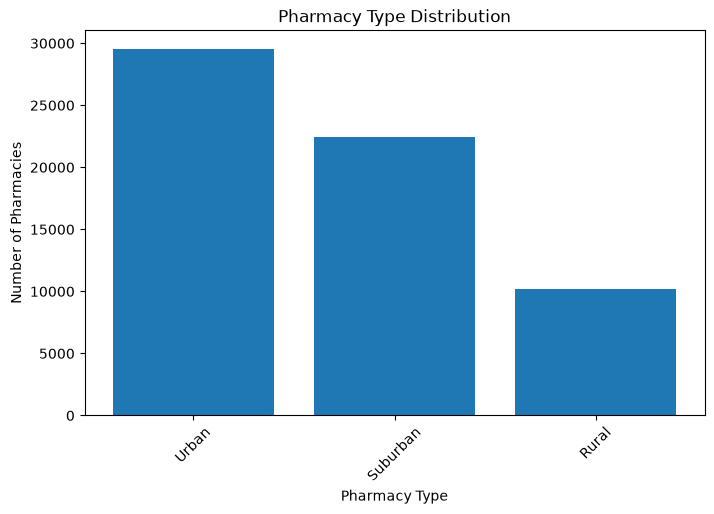

In [12]:
top_pharmacy = df["PharmacyType"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    top_pharmacy.index,
    top_pharmacy.values
)

plt.title("Pharmacy Type Distribution")
plt.xlabel("Pharmacy Type")
plt.ylabel("Number of Pharmacies")

plt.xticks(rotation=45)

plt.show()

Nous avons affiché le nombre d'occurrences de chaque marque

In [13]:
df["Brand"].value_counts()

Brand
PainLess        3689
Medica          3638
EuroRelief      3288
SmileBright     2960
AntiBioX        2935
BioBalance      2772
VitaCare        2497
AllerFree       2470
ColdAway        2464
FreshLine       2463
NutriCore       2279
ImmunoPlus      2267
GlucoSafe       2211
ZenHealth       2100
DermRx          2014
NeuroMed        1818
NatureFit       1714
CleanWave       1614
HairEssence     1582
DermaSoft       1570
CardioPro       1485
RxNova          1405
DigestEase      1366
HerbaLife       1351
CareEquip       1324
OncoAssist      1252
GlucoMeterX     1084
OrthoSupport    1053
HomeCheck        909
SkinGuard        884
MediTech         858
ThermoSense      823
Name: count, dtype: int64

Nous avons créé un diagramme en barres des 10 marques les plus fréquentes

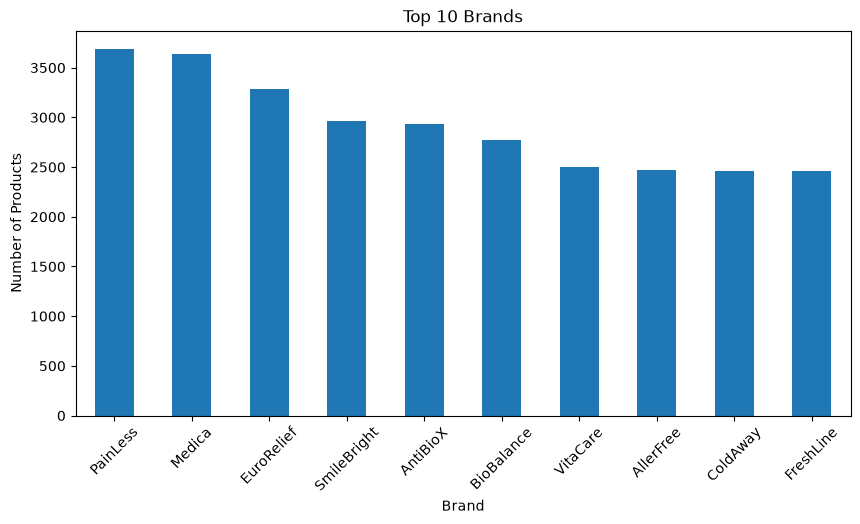

In [14]:
top_brands = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_brands.plot(kind="bar")

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

Nous avons affiché le nombre d'occurrences de chaque pays

In [15]:
df["Country"].value_counts()

Country
Germany        10628
France         10187
Italy           9872
Belgium         8280
Poland          6641
Netherlands     6138
Spain           5700
Austria         4693
Name: count, dtype: int64

Nous avons créé un diagramme en barres montrant le nombre d'enregistrements par pays

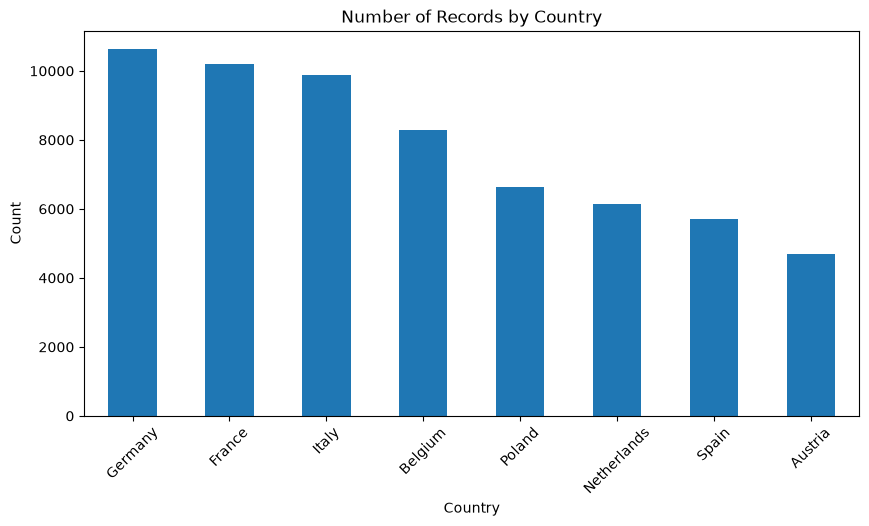

In [16]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(10,5))

country_counts.plot(kind="bar")

plt.title("Number of Records by Country")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Analyse univariée des variables numériques

Nous avons affiché les statistiques descriptives des revenus


In [17]:
df["RevenueEUR"].describe()

count    62139.000000
mean       138.946190
std        124.574712
min          1.610000
25%         55.250000
50%        102.750000
75%        181.350000
max       1036.280000
Name: RevenueEUR, dtype: float64

Nous avons créé un displot pour visualiser la distribution des revenus

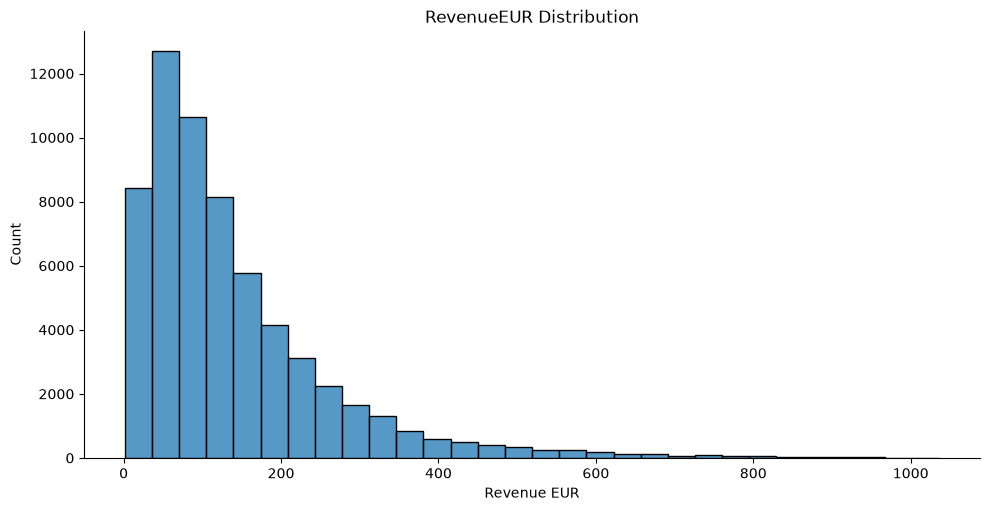

In [18]:
sns.displot(
    data=df,
    x="RevenueEUR",
    bins=30,
    height=5,
    aspect=2
)

plt.title("RevenueEUR Distribution")
plt.xlabel("Revenue EUR")

plt.show()

Nous avons affiché les statistiques descriptives des coûts

In [19]:
df["CostEUR"].describe()

count    62139.000000
mean        99.982881
std         93.611370
min          1.100000
25%         39.330000
50%         72.220000
75%        128.680000
max        834.420000
Name: CostEUR, dtype: float64

Nous avons créé un histplot pour visualiser la distribution des coûts

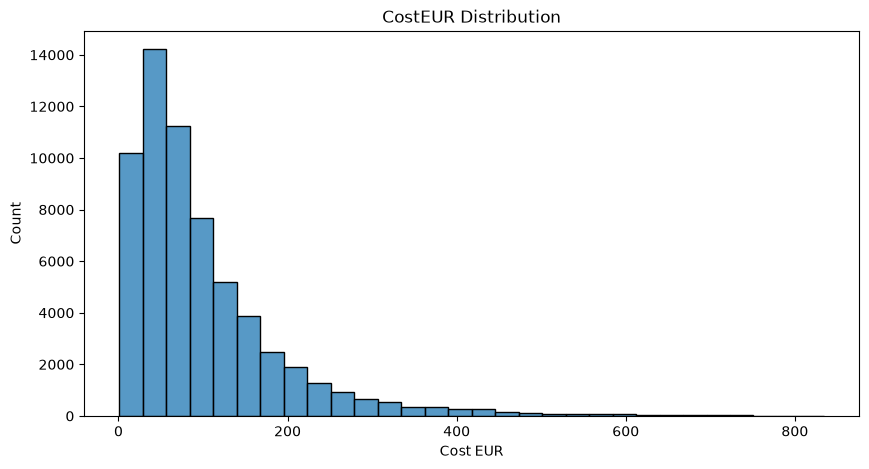

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="CostEUR",
    bins=30
)

plt.title("CostEUR Distribution")
plt.xlabel("Cost EUR")


plt.show()

Nous avons affiché les statistiques descriptives de la marge bénéficiaire


In [21]:
df["MarginEUR"].describe()

count    62139.000000
mean        38.963309
std         33.972445
min          0.440000
25%         15.140000
50%         28.990000
75%         51.990000
max        295.310000
Name: MarginEUR, dtype: float64

Nous avons créé un boxplot pour visualiser la marge bénéficiaire

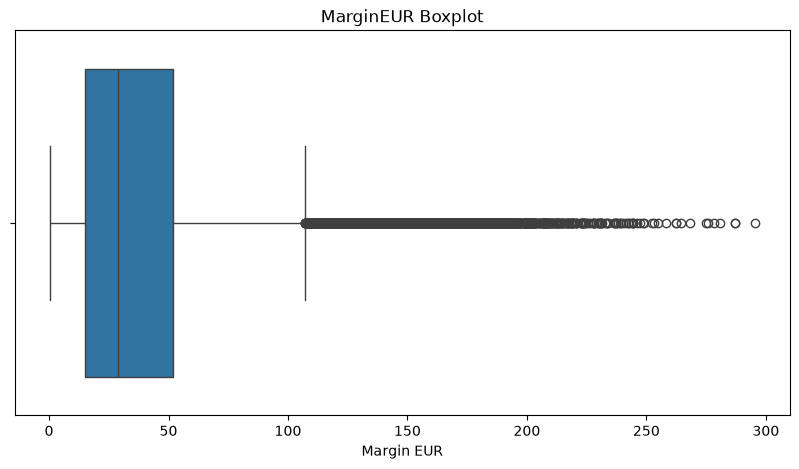

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="MarginEUR"
)

plt.title("MarginEUR Boxplot")
plt.xlabel("Margin EUR")

plt.show()

## Analyse multivariée

Nous avons calculé la moyenne des revenus pour chaque catégorie de produits

In [23]:
df.groupby("Category")["RevenueEUR"].mean()

Category
Medical Devices    144.202937
OTC                 92.588582
Personal Care      131.364865
Prescription       213.187177
Wellness           137.183119
Name: RevenueEUR, dtype: float64

Nous avons créé un diagramme en barres montrant la moyenne des revenus par catégorie de produits


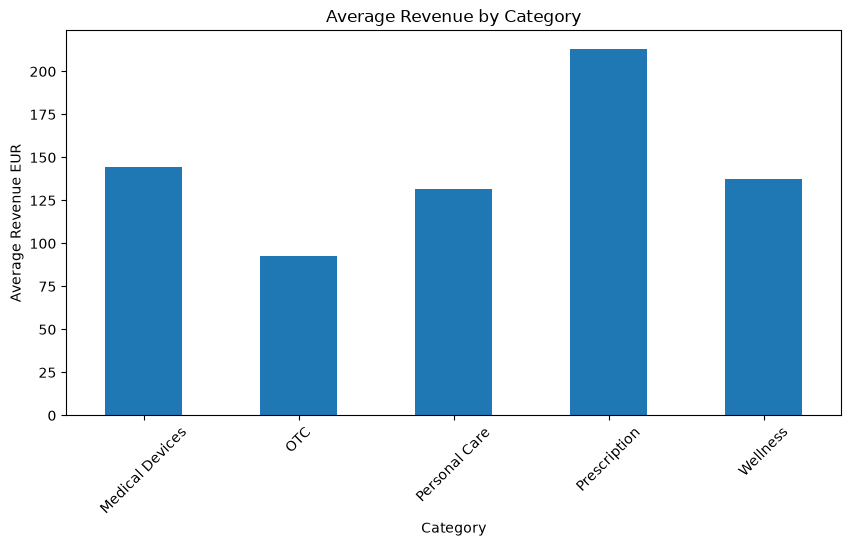

In [24]:

plt.figure(figsize=(10,5))

df.groupby("Category")["RevenueEUR"].mean().plot(
    kind="bar"
)

plt.title("Average Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Average Revenue EUR")

plt.xticks(rotation=45)

plt.show()

Nous avons calculé la somme de la marge bénéficiaire pour chaque marque

In [25]:
df.groupby("Brand")["MarginEUR"].sum()

Brand
AllerFree        57510.08
AntiBioX        169919.75
BioBalance      127775.11
CardioPro        44228.63
CareEquip        47621.22
CleanWave        69871.98
ColdAway         56186.49
DermRx           86135.05
DermaSoft        73139.38
DigestEase       47351.77
EuroRelief      100982.88
FreshLine        84448.15
GlucoMeterX      54145.60
GlucoSafe       105695.75
HairEssence      96453.18
HerbaLife        63523.51
HomeCheck        34983.25
ImmunoPlus      115744.58
MediTech         18647.06
Medica           82429.30
NatureFit        71261.05
NeuroMed        101464.96
NutriCore        96162.30
OncoAssist       46447.48
OrthoSupport     28419.97
PainLess        109221.15
RxNova           59274.77
SkinGuard        56860.71
SmileBright     106101.78
ThermoSense      33999.37
VitaCare         74484.36
ZenHealth       100650.45
Name: MarginEUR, dtype: float64

Nous avons créé un diagramme en barres des 10 meilleures marques selon la marge totale

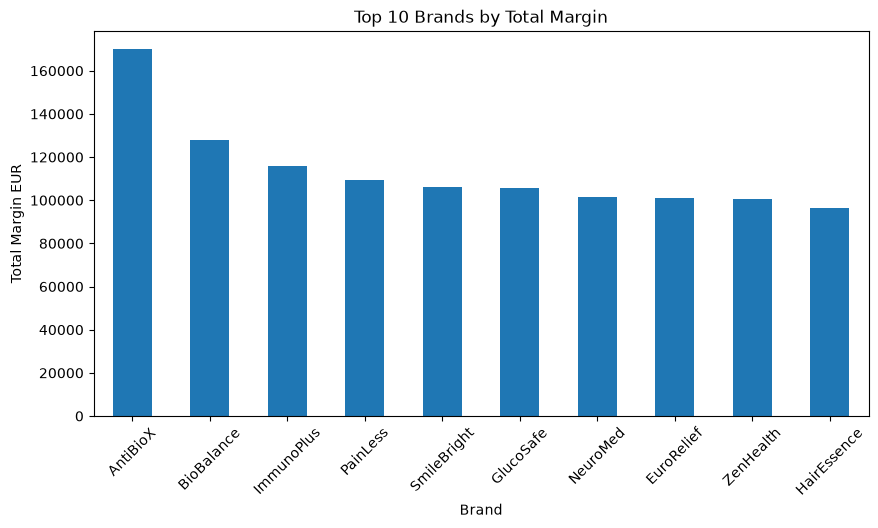

In [26]:
top10_brand_margin = (
    df.groupby("Brand")["MarginEUR"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top10_brand_margin.plot(kind="bar")

plt.title("Top 10 Brands by Total Margin")
plt.xlabel("Brand")
plt.ylabel("Total Margin EUR")

plt.xticks(rotation=45)

plt.show()

Nous avons créé un diagramme en barres montrant les revenus par pays

C:\Users\lonovo\AppData\Local\Temp\ipykernel_17148\2458714822.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


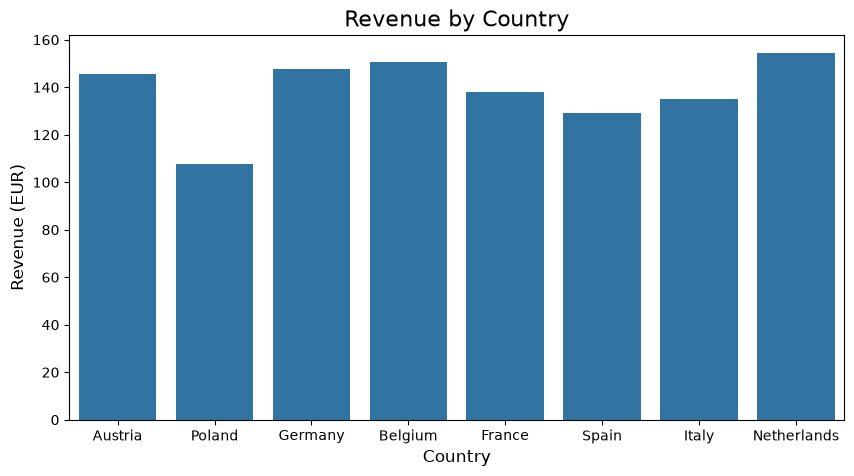

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Country",
    y="RevenueEUR",
    ci=None
)

plt.title("Revenue by Country", fontsize=16)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Revenue (EUR)", fontsize=12)

plt.show()

Nous avons créé un boxplot pour analyser la distribution des coûts par catégorie

Text(0.5, 1.0, 'Cost Distribution by Product Category')

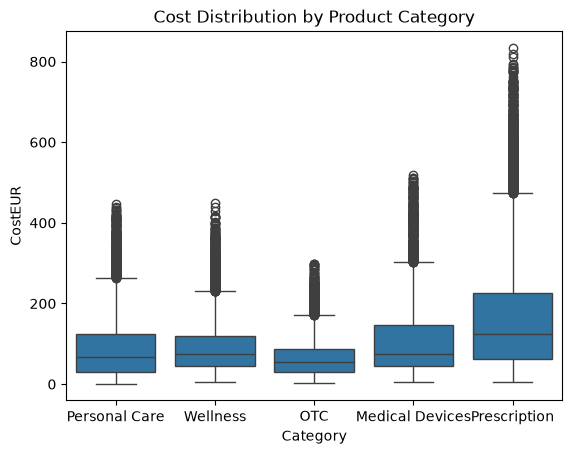

In [28]:
sns.boxplot(data=df,x="Category",y="CostEUR")
plt.title("Cost Distribution by Product Category")

Nous avons créé un boxplot pour analyser la distribution de la marge bénéficiaire par pays

Text(0.5, 1.0, 'Profit Margin Distribution by Country')

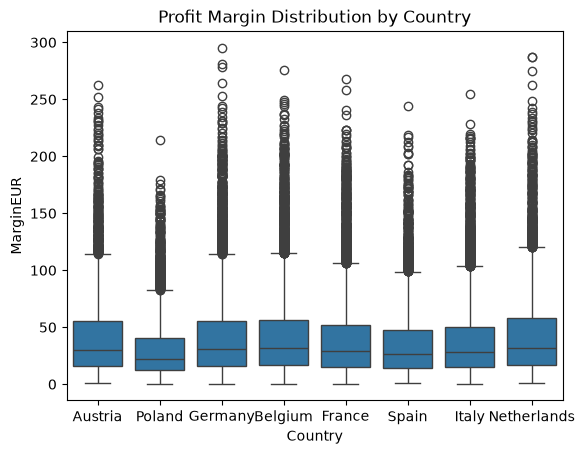

In [29]:
sns.boxplot(data=df,x="Country",y="MarginEUR")
plt.title("Profit Margin Distribution by Country")

Nous avons créé un scatterplot pour analyser la relation entre les revenus et les coûts

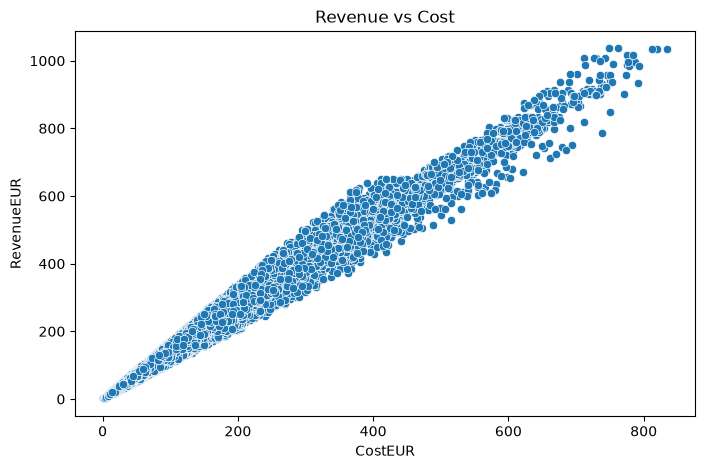

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="CostEUR",
    y="RevenueEUR"
)

plt.title("Revenue vs Cost")
plt.show()

## Tests statistiques et corrélations



Nous avons effectué un test ANOVA pour vérifier s'il existe une différence statistiquement significative entre les revenus des pays


In [31]:
#  H0 :  La moyenne des revenus est la même pour tous les pays 
#   H1 : La moyenne des revenus est la même pour tous les pays
from scipy.stats import f_oneway
groups = [group["RevenueEUR"] for name, group in df.groupby("Country")]


f_stat, p_value = f_oneway(*groups)


print("F-statistic:", f_stat)
print("P-value:", p_value)


if p_value < 0.05:
    print("There is a statistically significant difference between the countries.")
else:
    print("There is no statistically significant difference between the countries.")

F-statistic: 100.87290046975782
P-value: 2.3644813836557367e-147
There is a statistically significant difference between the countries.


Nous avons effectué un test de corrélation de Pearson pour analyser la relation statistique entre les revenus et les coûts


In [32]:
# H0 : Il n'existe pas de corrélation significative entre RevenueEUR et CostEUR
# H1 : Il existe une corrélation significative entre RevenueEUR et CostEUR
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["RevenueEUR"], df["CostEUR"])

print(f"Pearson Correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant correlation.")
else:
    print("There is no statistically significant correlation.")

Pearson Correlation: 0.992
P-value: 0.00000
There is a statistically significant correlation.


Nous avons créé une matrice de corrélation pour visualiser les relations entre les variables numériques

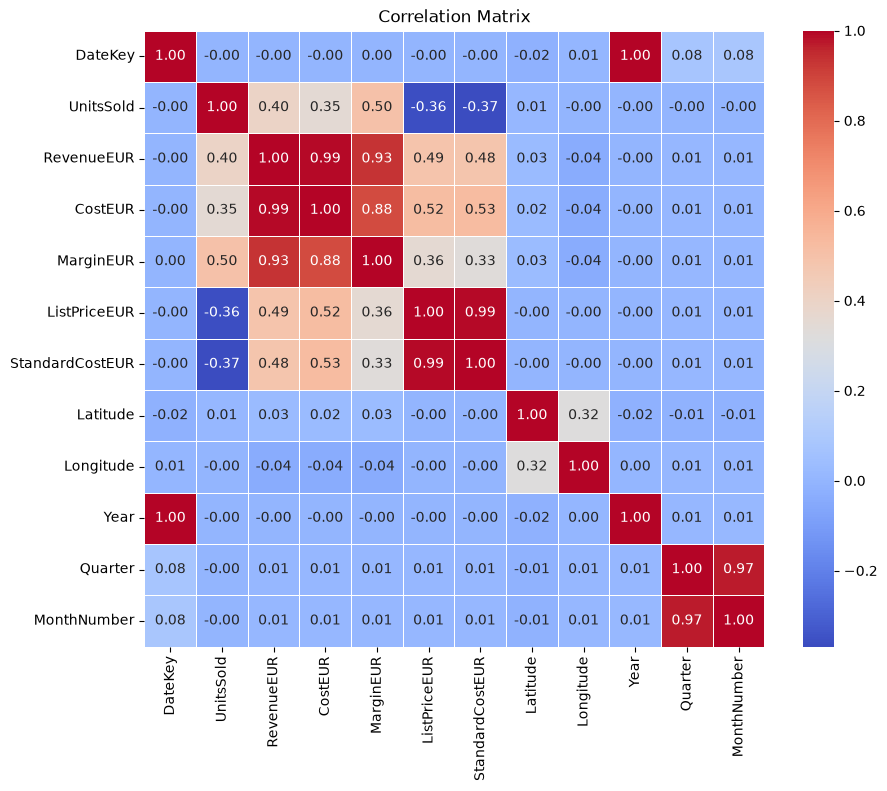

In [33]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='RevenueEUR'>

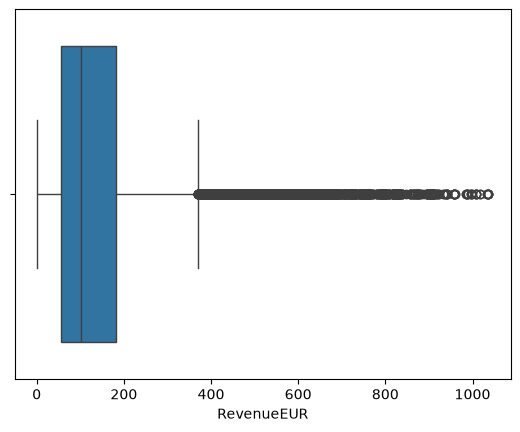

In [36]:
sns.boxplot(data=df,x="RevenueEUR")